# 4 · Interpretabilidad con LIME

**¿Qué es LIME?** *Local Interpretable Model-agnostic Explanations*. Un modelo de cientos de árboles es una
"caja negra": da una probabilidad pero no dice **por qué**. LIME explica **una predicción concreta**:
perturba el préstamo (cambia un poco sus variables), evalúa el modelo en cada
versión perturbada y ajusta un modelo lineal **simple** que imita al modelo **solo cerca de ese
préstamo**. Los coeficientes de ese modelo lineal son la explicación: qué variables empujaron la
predicción hacia "incumple" o hacia "paga".

**Qué se explica.** LIME se aplica **al modelo de mayor AUC de cada entorno entre los que
entregan probabilidades** (`LinearSVC` no las produce), sobre dos instancias **mal clasificadas**. Se
explican **los mismos dos préstamos** en los dos entornos, elegidos porque **ambos modelos ganadores
fallan en ellos** (sección 3.9):

* **Falso negativo:** un préstamo que **incumplió** y que ambos modelos dejaron pasar con una
  probabilidad muy baja.
* **Falso positivo:** un préstamo que **se pagó** y que ambos modelos marcaron como riesgoso.

```{note}
LIME se aplica en el espacio de las **variables originales** (no en el de las columnas One-Hot),
para que "purpose = credit_card" se lea como una sola variable. El adaptador está en
`src/lc_utils.py::LimeAdapter`. La parte de PySpark se ejecutó **dentro de la sesión de Spark del
capítulo 3** (el modelo vive allí); aquí se leen sus resultados (`resultados/lime_spark.json`).
```

In [1]:
import json
import platform
import sys
import time
import warnings
from pathlib import Path

import joblib
import lime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sys.path.insert(0, str(Path.cwd().parent))
from src import lc_models as lm  # noqa: E402
from src import lc_utils as lc  # noqa: E402

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
RESULTS, DATA_DIR = Path("../resultados"), Path("../data")
print(f"Python {platform.python_version()}")

Python 3.10.21


## 4.1 Datos y modelo de scikit-learn

Se reconstruye la tabla con las mismas reglas y la misma partición, y se carga el **modelo de mayor AUC
entre los que dan probabilidades**, entrenado en el capítulo 2.

In [2]:
m = lc.build_model_frame(lc.load_raw(usecols=lc.RAW_COLUMNS))
split = pd.read_parquet(DATA_DIR / "split_ids.parquet")
assert split["id"].equals(m["id"])
es_test = (split["split"] == "test").to_numpy()
train, test = m.loc[~es_test].reset_index(drop=True), m.loc[es_test].reset_index(drop=True)
art = joblib.load(DATA_DIR / "models" / "sk_lime_model.joblib")
prep, scaler, modelo, clave, THR = art["prep"], art["scaler"], art["model"], art["clave"], art["threshold"]
ids = json.loads((RESULTS / "instancias_lime.json").read_text())
print(f"Modelo de scikit-learn explicado: {lm.NOMBRES[clave]} · umbral de decisión (F1 fuera de pliegue) = {THR:.3f}")


def predict_df(df: pd.DataFrame) -> np.ndarray:
    """DataFrame de variables crudas -> probabilidad de incumplimiento (preprocesamiento + modelo)."""
    x = prep.transform(df[lc.FEATURES]).astype(np.float32)
    if scaler is not None:
        x = scaler.transform(x)
    return modelo.predict_proba(x)[:, 1]


casos = {"Falso negativo": ids["FN"]["id"], "Falso positivo": ids["FP"]["id"]}
filas = {k: test[test["id"] == v].reset_index(drop=True) for k, v in casos.items()}
for k, f in filas.items():
    p = float(predict_df(f)[0])
    print(f"{k}: préstamo {casos[k]} · probabilidad del modelo de scikit-learn = {p:.3f} · realidad: "
          f"{'incumplió' if f['default'][0] == 1 else 'pagó'} · predijo {'incumple' if p >= THR else 'paga'} (umbral {THR:.3f})")

Modelo de scikit-learn explicado: Gradient boosting · umbral de decisión (F1 fuera de pliegue) = 0.224
Falso negativo: préstamo 36099806 · probabilidad del modelo de scikit-learn = 0.020 · realidad: incumplió · predijo paga (umbral 0.224)
Falso positivo: préstamo 55961482 · probabilidad del modelo de scikit-learn = 0.826 · realidad: pagó · predijo incumple (umbral 0.224)


## 4.2 Construcción del explicador

`LimeTabularExplainer` necesita **datos de referencia** para conocer la distribución de cada variable
(cuartiles para discretizar las continuas, frecuencias de las categorías). Se usan 20 000 filas de
**entrenamiento** al azar (no del conjunto de prueba). Estos datos **no** entrenan nada: solo describen cómo suelen ser
las variables.

In [3]:
ref = train.sample(20_000, random_state=lc.SEED)
adapter = lc.LimeAdapter(ref, predict_df, extra=pd.concat(filas.values()))

## 4.3 Explicación de los dos errores (scikit-learn)

In [4]:
explicaciones, tiempos = {}, {}
for k, f in filas.items():
    t0 = time.time()
    explicaciones[k] = adapter.explain(f, num_features=10, num_samples=5000)
    tiempos[k] = time.time() - t0
    e = explicaciones[k]
    print(f"\n=== {k} (préstamo {casos[k]}) · explicación calculada en {tiempos[k]:.1f} s ===")
    print(f"Probabilidad del modelo: {predict_df(f)[0]:.3f} · predicción del modelo lineal local: "
          f"{e.local_pred[0]:.3f} · R² local = {e.score:.3f}")
    display(pd.DataFrame(e.as_list(label=1), columns=["condición de la variable", "peso (hacia 'incumple' si > 0)"]))


=== Falso negativo (préstamo 36099806) · explicación calculada en 0.1 s ===
Probabilidad del modelo: 0.020 · predicción del modelo lineal local: -0.046 · R² local = 0.501


,condición de la variable,peso (hacia 'incumple' si > 0)
0,int_rate <= 9.75,-0.1234
1,term_months <= 36.00,-0.0807
2,fico_range_high > 714.00,-0.0410
3,dti <= 11.89,-0.0364
4,home_ownership=MORTGAGE,-0.0298
5,open_acc <= 8.00,-0.0220
6,inq_last_6mths <= 0.00,-0.0183
7,annual_inc > 90000.00,-0.0164
8,revol_bal > 20100.25,-0.0156
9,1.00 < mort_acc <= 3.00,-0.0144



=== Falso positivo (préstamo 55961482) · explicación calculada en 0.1 s ===
Probabilidad del modelo: 0.826 · predicción del modelo lineal local: 0.367 · R² local = 0.584


,condición de la variable,peso (hacia 'incumple' si > 0)
0,int_rate > 15.88,0.1380
1,term_months > 36.00,0.0858
2,fico_range_high > 714.00,-0.0388
3,dti <= 11.89,-0.0376
4,home_ownership=RENT,0.0287
5,annual_inc > 90000.00,-0.0236
6,loan_amnt > 20000.00,0.0217
7,inq_last_6mths > 1.00,0.0200
8,mort_acc <= 0.00,0.0185
9,revol_bal <= 5920.00,0.0164


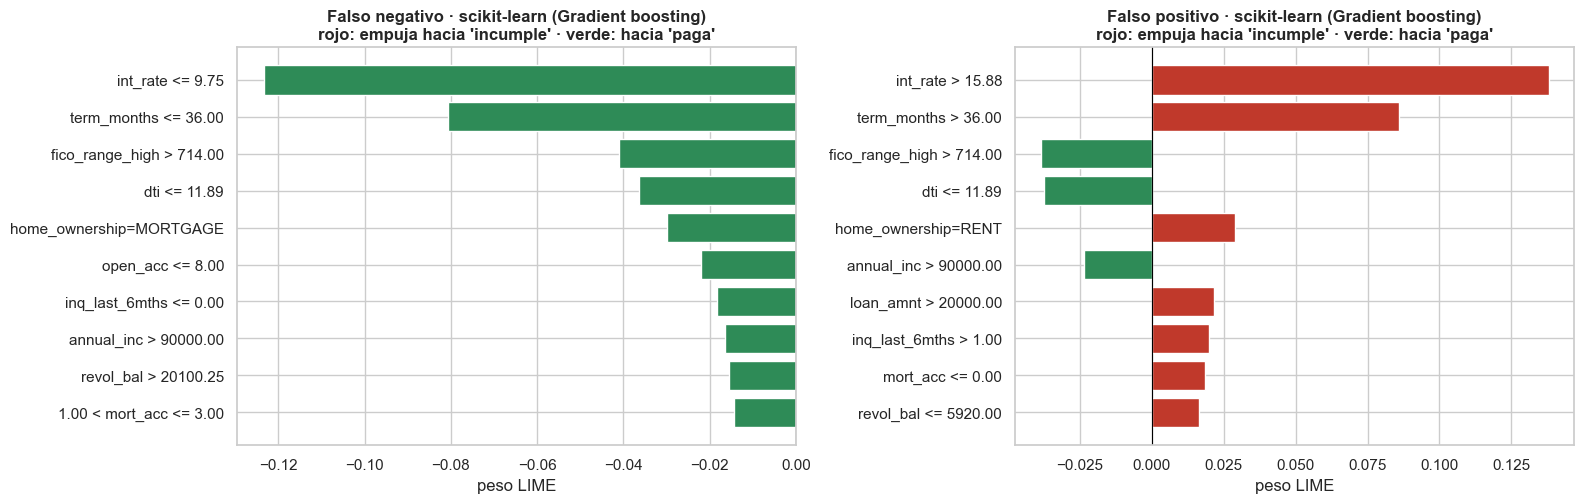

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5.2))
for a, (k, e) in zip(ax, explicaciones.items()):
    lista = e.as_list(label=1)[::-1]
    pesos = [w for _, w in lista]
    a.barh([n for n, _ in lista], pesos, color=["#c0392b" if w > 0 else "#2e8b57" for w in pesos])
    a.axvline(0, color="black", lw=0.8)
    a.set(title=f"{k} · scikit-learn ({lm.NOMBRES[clave]})\nrojo: empuja hacia 'incumple' · verde: hacia 'paga'", xlabel="peso LIME")
plt.tight_layout()
plt.show()

**Cómo se lee.** Cada barra es una condición de una variable ("int_rate > 15.88") y su peso: rojo
aumenta la probabilidad de incumplimiento, verde la reduce, para ese préstamo. R² local indica qué
tan bien el modelo lineal simple imita al modelo original cerca de esa instancia.

```{important}
LIME explica **al modelo**, no a la realidad del préstamo: los pesos describen qué llevó al modelo a
dar esa probabilidad, no una relación de causa y efecto. La fidelidad local aquí es moderada
(R² entre 0.50 y 0.58 en scikit-learn, entre 0.51 y 0.55 en PySpark), así que estas explicaciones son
descriptivas y no deben usarse como justificación causal, ni como base única de una decisión de
crédito individual. Además, el modelo lineal local no reproduce bien la probabilidad del modelo en todos
los casos: para el falso positivo predice 0.37 frente a 0.83 del modelo, y para el falso negativo llega a
un valor negativo (−0.05).
```

## 4.4 ¿Es estable la explicación? (limitación de LIME)

LIME **muestrea al azar**: dos ejecuciones sobre el mismo préstamo pueden dar explicaciones algo
distintas. Se repite 5 veces el falso negativo con distinta semilla y se compara qué variables
aparecen entre las 5 más importantes.

In [6]:
from lime.lime_tabular import LimeTabularExplainer  # noqa: E402

fila = filas["Falso negativo"]
top = []
for seed in range(5):
    ex = LimeTabularExplainer(adapter.encode(ref), feature_names=lc.FEATURES, categorical_features=adapter.cat_idx,
                              categorical_names={lc.FEATURES.index(c): adapter.levels[c] for c in lc.CATEGORICAL},
                              class_names=["pagado", "incumplido"], discretize_continuous=True, random_state=seed)
    e = ex.explain_instance(adapter.encode(fila)[0], adapter.predict_proba, labels=(1,), num_features=5, num_samples=5000)
    top.append([lc.FEATURES[i] for i, _ in sorted(e.as_map()[1], key=lambda t: -abs(t[1]))])
tabla_est = pd.DataFrame(top, index=[f"semilla {s}" for s in range(5)], columns=[f"top {i + 1}" for i in range(5)])
display(tabla_est)
freq = pd.Series([v for fila_ in top for v in fila_]).value_counts()
print("Frecuencia con la que cada variable aparece entre las 5 principales (de 5 ejecuciones):")
print(freq.to_string())

,top 1,top 2,top 3,top 4,top 5
semilla 0,int_rate,term_months,fico_range_high,dti,home_ownership
semilla 1,int_rate,term_months,fico_range_high,dti,home_ownership
semilla 2,int_rate,term_months,fico_range_high,dti,home_ownership
semilla 3,int_rate,term_months,fico_range_high,dti,home_ownership
semilla 4,int_rate,term_months,fico_range_high,dti,home_ownership


Frecuencia con la que cada variable aparece entre las 5 principales (de 5 ejecuciones):
int_rate           5
term_months        5
fico_range_high    5
dti                5
home_ownership     5


## 4.5 De lo local a lo global (agregando muchas explicaciones)

LIME explica **un préstamo a la vez**. Para ver qué variables importan *en general* se promedia el valor
absoluto del peso sobre 60 préstamos de prueba al azar.

60 explicaciones en 3 s


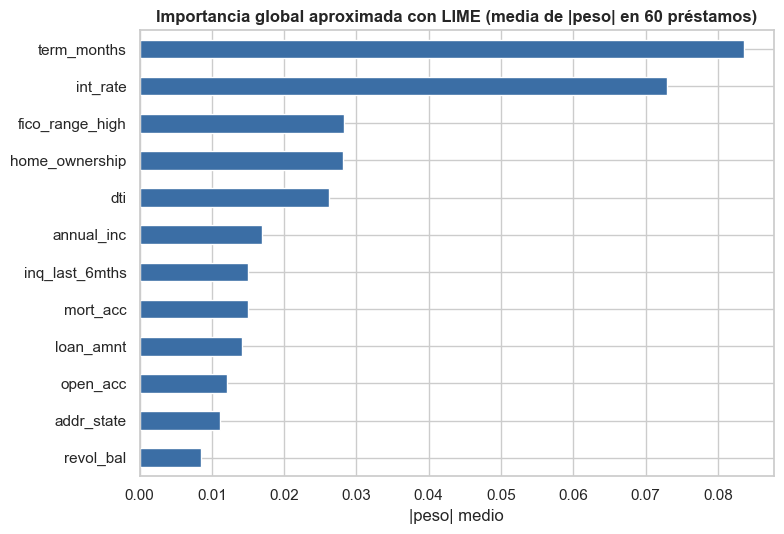

In [7]:
muestra = test.sample(60, random_state=lc.SEED).reset_index(drop=True)
acum = pd.Series(0.0, index=lc.FEATURES)
t0 = time.time()
for i in range(len(muestra)):
    e = adapter.explain(muestra.iloc[[i]], num_features=len(lc.FEATURES), num_samples=2000)
    for j, w in e.as_map()[1]:
        acum.iloc[j] += abs(w)
print(f"60 explicaciones en {time.time() - t0:.0f} s")
acum = (acum / len(muestra)).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5.5))
acum.head(12).iloc[::-1].plot.barh(ax=ax, color="#3b6ea5")
ax.set(title="Importancia global aproximada con LIME (media de |peso| en 60 préstamos)", xlabel="|peso| medio")
plt.tight_layout()
plt.show()

## 4.6 Los mismos préstamos con el modelo de PySpark

La sección 3.9 aplicó LIME **dentro de la sesión de Spark** al modelo de mayor AUC de PySpark entre los que
dan probabilidades, con **los mismos dos préstamos** y los mismos parámetros de LIME (5 000 muestras
perturbadas, 10 variables). Aquí se comparan las dos explicaciones.

Modelo de PySpark explicado: Gradient boosting


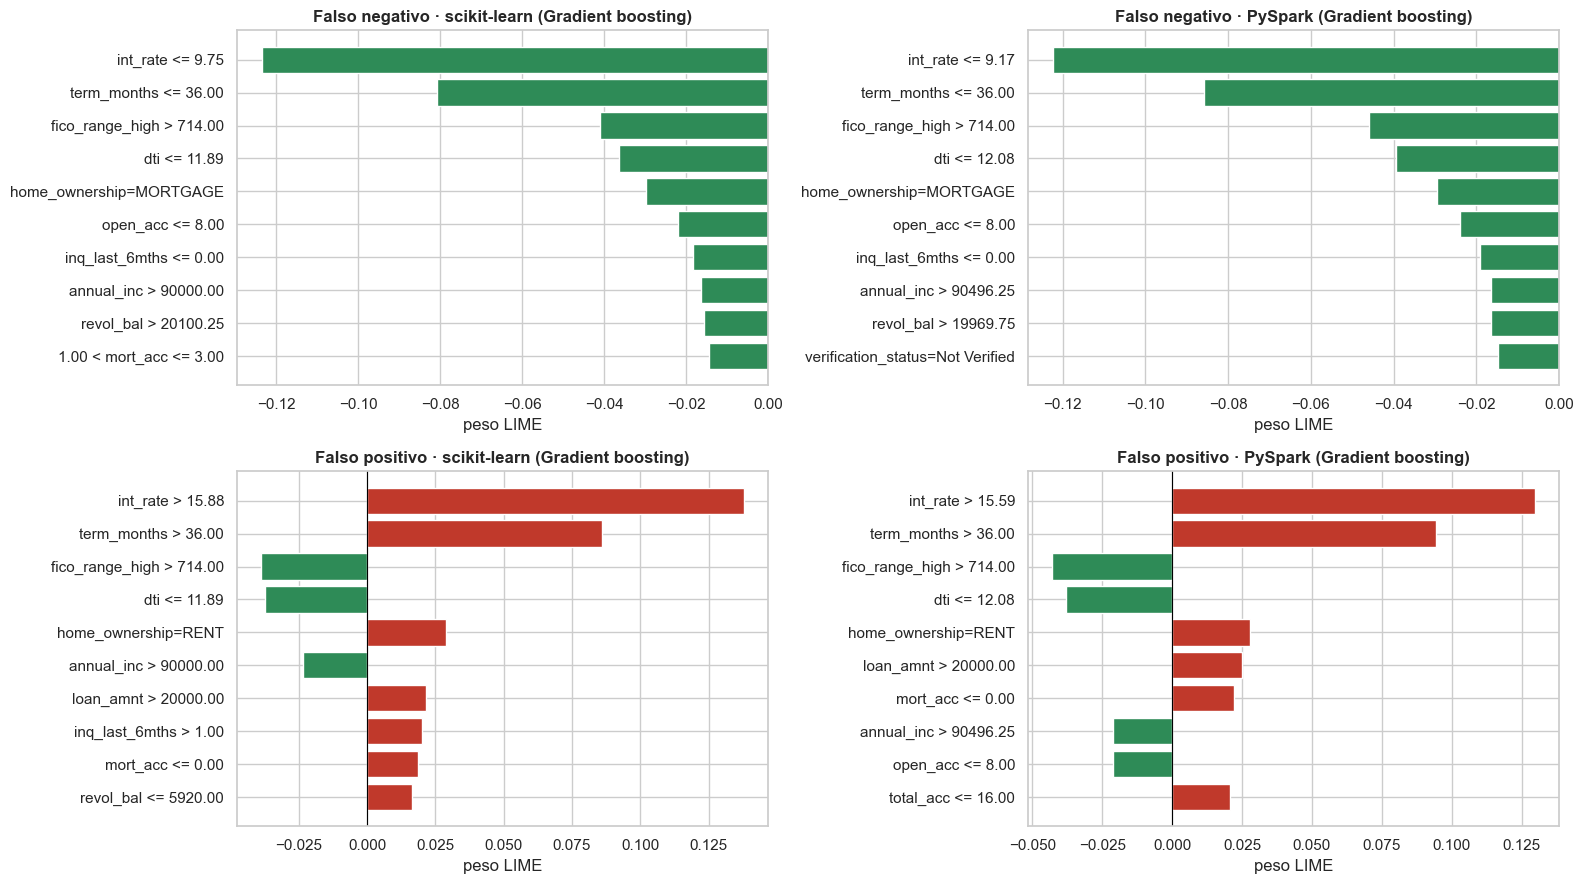

,variables en común (de 10),R² local scikit-learn,R² local PySpark,prob. scikit-learn,prob. PySpark,tiempo scikit-learn (s),tiempo PySpark (s)
instancia,,,,,,,
Falso negativo,9,0.5008,0.5100,0.0201,0.0221,0.0998,0.5591
Falso positivo,8,0.5842,0.5538,0.8256,0.8631,0.0713,0.5573


In [8]:
sp = json.loads((RESULTS / "lime_spark.json").read_text())
print(f"Modelo de PySpark explicado: {lm.NOMBRES[sp['modelo']]}")
fig, ax = plt.subplots(2, 2, figsize=(16, 9))
for fila_ax, (k, nombre) in zip(ax, (("FN", "Falso negativo"), ("FP", "Falso positivo"))):
    e_sk = explicaciones[nombre].as_list(label=1)[::-1]
    e_sp = sp["instancias"][k]["pesos"][::-1]
    for a, lista, titulo in ((fila_ax[0], e_sk, f"{nombre} · scikit-learn ({lm.NOMBRES[clave]})"),
                             (fila_ax[1], e_sp, f"{nombre} · PySpark ({lm.NOMBRES[sp['modelo']]})")):
        pesos = [w for _, w in lista]
        a.barh([n for n, _ in lista], pesos, color=["#c0392b" if w > 0 else "#2e8b57" for w in pesos])
        a.axvline(0, color="black", lw=0.8)
        a.set(title=titulo, xlabel="peso LIME")
plt.tight_layout()
plt.show()


def _vars(lista):
    """Nombres de las variables (sin la condición) de una explicación de LIME."""
    out = []
    for cond, _ in lista:
        for v in lc.FEATURES:
            if v in cond:
                out.append(v)
                break
    return out


coinc = []
for k, nombre in (("FN", "Falso negativo"), ("FP", "Falso positivo")):
    v_sk, v_sp = _vars(explicaciones[nombre].as_list(label=1)), _vars(sp["instancias"][k]["pesos"])
    coinc.append({"instancia": nombre, "variables en común (de 10)": len(set(v_sk) & set(v_sp)),
                  "R² local scikit-learn": explicaciones[nombre].score, "R² local PySpark": sp["instancias"][k]["r2_local"],
                  "prob. scikit-learn": ids[k]["p_sklearn"], "prob. PySpark": ids[k]["p_spark"],
                  "tiempo scikit-learn (s)": tiempos[nombre], "tiempo PySpark (s)": sp["instancias"][k]["tiempo_s"]})
display(pd.DataFrame(coinc).set_index("instancia"))

## 4.7 LIME y PySpark: qué cambia y qué limita

LIME **no es distribuido**: corre en la memoria de un solo proceso y necesita una función
`predict_proba` a la que llamar miles de veces. Con un modelo de PySpark eso significa:

1. **Cada llamada es un viaje a la JVM**: crear un DataFrame de Spark con las muestras perturbadas,
   aplicar el preprocesamiento y el modelo, y traer las probabilidades de vuelta. Es el caso más
   desfavorable para Spark (mucha latencia fija, poco cómputo por llamada). **Sin Apache Arrow esa
   latencia llegó a ≈ 7–8 minutos por llamada** (capítulo 3b).
2. **Datos de referencia locales**: LIME necesita una muestra de los datos en el driver para conocer las
   distribuciones. Con datos realmente masivos (que no caben en memoria) hay que recurrir a una
   **muestra** (aquí, 20 000 filas), lo que contradice el principio de no mover el conjunto de datos al *driver*.
3. **Perturbaciones sin correlaciones**: LIME muestrea cada variable por separado y puede crear préstamos
   imposibles (p. ej. tasa muy baja con FICO muy bajo), sobre los que el modelo nunca fue entrenado.
4. **Costo por instancia**: aunque en la sección 4.4 el orden de las variables no cambió entre semillas,
   LIME es aleatorio por diseño y hay que ejecutarlo para **cada** instancia; no escala a millones de
   préstamos.

En entornos distribuidos suelen preferirse explicaciones **específicas de árboles** (por ejemplo valores
SHAP para árboles; Lundberg *et al.*, 2020), que se calculan a partir de la estructura del propio
modelo, sin perturbar los datos.

In [9]:
res_sk = json.loads((RESULTS / "sk_resultados.json").read_text())
lat = pd.DataFrame({"scikit-learn": res_sk["latencia_predict_s"], "PySpark (con Arrow)": sp["latencia_predict_s"]})
lat["PySpark / scikit-learn"] = lat.iloc[:, 1] / lat.iloc[:, 0]
lat.index.name = "filas por llamada"
display(lat.style.format({c: "{:.4f}" if c != "PySpark / scikit-learn" else "{:.0f}×" for c in lat.columns}))
print(f"Cada explicación de LIME hace UNA llamada de 5 000 muestras: scikit-learn ≈ {lat.iloc[-1, 0]:.2f} s · PySpark ≈ {lat.iloc[-1, 1]:.2f} s "
      "por préstamo explicado (solo la predicción).")

,scikit-learn,PySpark (con Arrow),PySpark / scikit-learn
filas por llamada,,,
1,0.0002,0.2870,1188×
100,0.0006,0.2746,489×
5000,0.0135,0.5108,38×


Cada explicación de LIME hace UNA llamada de 5 000 muestras: scikit-learn ≈ 0.01 s · PySpark ≈ 0.51 s por préstamo explicado (solo la predicción).
